In [1]:
import os
import os.path as op
import numpy as np
import pandas as pd

bids_folder= '/shares/zne.uzh/mrenke/ds-stressrisk'
subject_list = [f[4:] for f in os.listdir(bids_folder) if f[0:3] == 'sub' and len(f) == 6]
all_subjects_set = set(subject_list)
sub_array= np.array([int(i) for i in subject_list]) 

group_mapping = pd.read_csv(op.join(bids_folder,'group_assignmentList.csv'))[['subject','group']].set_index('subject')


/data/mrenke/conda/envs/numrefields/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
from stress_risk.utils.data import Subject
from nilearn.maskers import NiftiMasker
from nilearn import image

def get_vselect_mask(sub, bids_folder):
    roi='NPC_R'
    source_key_vselect = 'encoding_model.cv.denoise.retroicor'
    session1 = 1
    subject = Subject(int(sub), bids_folder=bids_folder)
    ips_mask = subject.get_volume_mask(roi=roi, session=1, epi_space=True) # anat from session1
    ips_masker = NiftiMasker(mask_img=ips_mask)
    im_cvr2_fn = op.join(bids_folder, 'derivatives', source_key_vselect, f'sub-{sub}', f'ses-{session1}','func', f'sub-{sub}_ses-{session1}_desc-cvr2.optim_space-T1w_pars.nii.gz')
    im_cvr2 = image.load_img(im_cvr2_fn)
    cv_r2 = pd.DataFrame(ips_masker.fit_transform(im_cvr2))
    r2_mask = cv_r2 > 0.0
    r2_mask = r2_mask.to_numpy().flatten()
    print(f'Number of voxels: {r2_mask.sum()}')
    return r2_mask
    

/data/mrenke/conda/envs/numrefields/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
key = 'encoding_model.model6.retroicor'
param = 'mu'

difs = []
difs_mean = []
difs_sd = []
for sub in subject_list:
    r2_mask = get_vselect_mask(sub, bids_folder)
    fn1 = op.join(bids_folder, 'derivatives', key, f'sub-{sub}', 'func', f'sub-{sub}_desc-{param}.1.optim_space-T1w_pars.npy')
    dat_mu1 = np.load(fn1)[r2_mask]
    fn2 = op.join(bids_folder, 'derivatives', key, f'sub-{sub}', 'func', f'sub-{sub}_desc-{param}.2.optim_space-T1w_pars.npy')
    dat_mu2 = np.load(fn2)[r2_mask]
    dif = dat_mu2 - dat_mu1
    difs.append(dif)
    difs_mean.append(dif.mean())
    difs_sd.append(dif.std())


## Plot results 

In [4]:
df = pd.DataFrame(np.array(difs_mean), index=sub_array,columns=['mean_mu_dif'])
df.index.name = 'subject'
df = df.join(group_mapping).set_index('group',append=True)

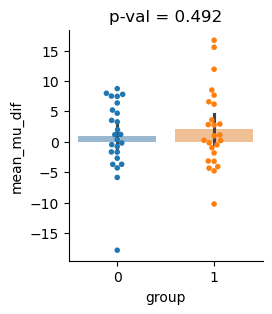

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

y_var = 'mean_mu_dif'
tmp = df.copy()

_, p_value = ttest_ind(tmp.xs(0,0,'group'),tmp.xs(1,0,'group'), equal_var=False)  # Welch's t-test

fig, ax = plt.subplots(1,1, figsize=(2.5,3)) # , sharex=True, sharey=True
sns.barplot(data=tmp.reset_index(), x ='group', y =y_var ,hue='group', alpha=0.5,legend=False, ax=ax)
sns.swarmplot(data=tmp.reset_index(), y =y_var , x ='group', hue='group',size=4,legend=False, ax=ax)
ax.set(title=f'p-val = {p_value[0]:.3f}')

sns.despine()

(array([ 5.,  1.,  8.,  7., 13.,  2., 15., 20., 15.,  7.]),
 array([-43.337883 , -34.217014 , -25.096148 , -15.975279 ,  -6.854411 ,
          2.2664566,  11.387324 ,  20.508192 ,  29.62906  ,  38.749928 ,
         47.870796 ], dtype=float32),
 <BarContainer object of 10 artists>)

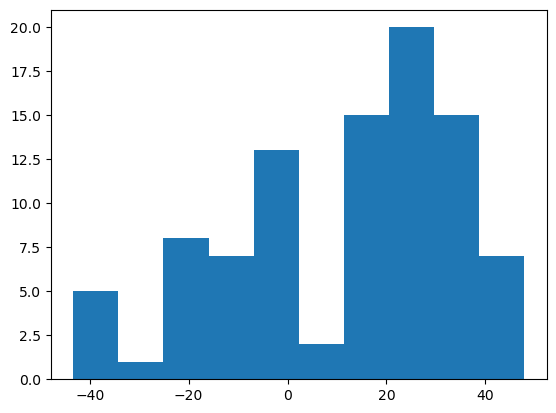

In [6]:
plt.hist(difs[0])

(array([ 1.,  8.,  9., 10., 11., 17.,  9., 10.,  8., 17.]),
 array([-1.887785 ,  3.8364184,  9.560621 , 15.284825 , 21.009027 ,
        26.73323  , 32.457436 , 38.181637 , 43.90584  , 49.630043 ,
        55.354248 ], dtype=float32),
 <BarContainer object of 10 artists>)

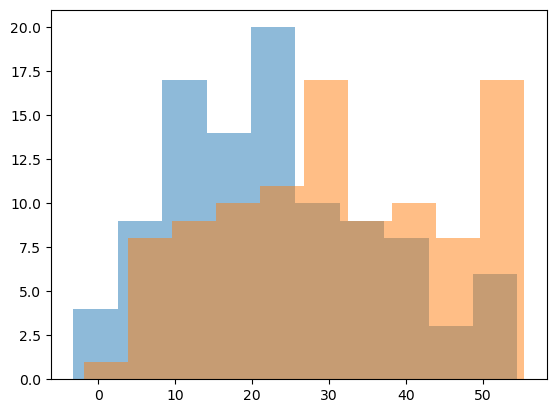

In [7]:
plt.hist(dat_mu1,alpha=0.5)
plt.hist(dat_mu2,alpha=0.5)


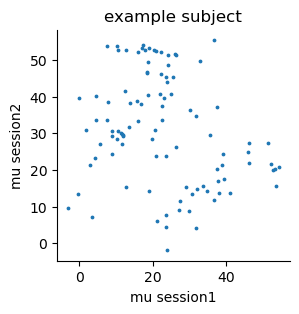

In [20]:
fig, axs = plt.subplots(1,1, figsize=(3,3),sharey=True) # , sharex=True, sharey=True
axs.set(xlabel='mu session1', ylabel='mu session2', title='example subject')
axs.scatter(dat_mu1,dat_mu2, s=3)
sns.despine()

In [ ]:
# only use voxels with mu (from ses 1) >/< 25

thresh = 25

key = 'encoding_model.model6.retroicor'
param = 'mu'

meanDifs_larger25 = []
meanDifs_smaller25 = []
for sub in subject_list:
    r2_mask = get_vselect_mask(sub, bids_folder)
    fn1 = op.join(bids_folder, 'derivatives', key, f'sub-{sub}', 'func', f'sub-{sub}_desc-{param}.1.optim_space-T1w_pars.npy')
    dat_mu1 = np.load(fn1)[r2_mask]
    fn2 = op.join(bids_folder, 'derivatives', key, f'sub-{sub}', 'func', f'sub-{sub}_desc-{param}.2.optim_space-T1w_pars.npy')
    dat_mu2 = np.load(fn2)[r2_mask]
    dif = dat_mu2 - dat_mu1
    meanDifs_larger25.append(dif[dat_mu1 > thresh].mean())
    meanDifs_smaller25.append(dif[dat_mu1 < thresh].mean())


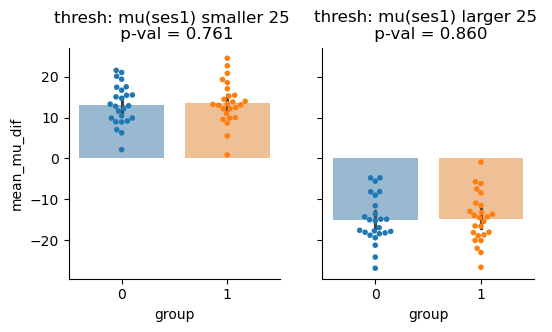

In [ ]:
y_var = 'mean_mu_dif'
fig, axs = plt.subplots(1,2, figsize=(6,3),sharey=True) # , sharex=True, sharey=True

for i, spec in enumerate(['smaller', 'larger']):
    difs = meanDifs_smaller25 if spec ==  'smaller' else meanDifs_larger25
    df = pd.DataFrame(np.array(difs), index=sub_array,columns=['mean_mu_dif'])
    df.index.name = 'subject'
    df = df.join(group_mapping).set_index('group',append=True)
    tmp = df.copy()

    _, p_value = ttest_ind(tmp.xs(0,0,'group'),tmp.xs(1,0,'group'), equal_var=False)  # Welch's t-test
    sns.barplot(data=tmp.reset_index(), x ='group', y =y_var ,hue='group', alpha=0.5,legend=False, ax=axs[i])
    sns.swarmplot(data=tmp.reset_index(), y =y_var , x ='group', hue='group',size=4,legend=False, ax=axs[i])
    axs[i].set(title=f'thresh: mu(ses1) {spec} {thresh} \n p-val = {p_value[0]:.3f}')
    sns.despine()

In [27]:
param = 'mu'
sub ='48'
r2_mask = get_vselect_mask(sub, bids_folder)
fn1 = op.join(bids_folder, 'derivatives', key, f'sub-{sub}', 'func', f'sub-{sub}_desc-{param}.1.optim_space-T1w_pars.npy')
dat_mu1 = np.load(fn1)
fn2 = op.join(bids_folder, 'derivatives', key, f'sub-{sub}', 'func', f'sub-{sub}_desc-{param}.2.optim_space-T1w_pars.npy')
dat_mu2 = np.load(fn2)
dif = (dat_mu2 - dat_mu1)


/data/mrenke/conda/envs/numrefields/lib/python3.9/site-packages/nilearn/image/resampling.py:627: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  return new_img_like(img, resampled_data, target_affine)


Number of voxels: 55


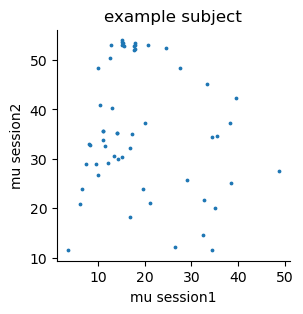

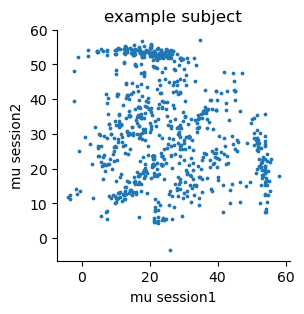

In [28]:
fig, axs = plt.subplots(1,1, figsize=(3,3),sharey=True) # , sharex=True, sharey=True
axs.set(xlabel='mu session1', ylabel='mu session2', title='example subject')
axs.scatter(dat_mu1[r2_mask],dat_mu2[r2_mask], s=3)
sns.despine()

fig, axs = plt.subplots(1,1, figsize=(3,3),sharey=True) # , sharex=True, sharey=True
axs.set(xlabel='mu session1', ylabel='mu session2', title='example subject')
axs.scatter(dat_mu1,dat_mu2, s=3)
sns.despine()

# Visualize R2 on brain surface

In [17]:
from nipype.interfaces.freesurfer import SurfaceTransform

def transform_fsaverage5(in_file, fs_hemi, source_subject, bids_folder):

    subjects_dir = op.join(bids_folder, 'derivatives', 'freesurfer')

    sxfm = SurfaceTransform(subjects_dir=subjects_dir)
    sxfm.inputs.source_file = in_file
    sxfm.inputs.out_file = in_file.replace('fsnative', 'fsaverage5')
    sxfm.inputs.source_subject = source_subject
    sxfm.inputs.target_subject = 'fsaverage5'
    sxfm.inputs.hemi = fs_hemi

    r = sxfm.run()

In [4]:
from  nilearn.datasets import fetch_surf_fsaverage

# for plotting
fsaverage = fetch_surf_fsaverage() # default 5

In [ ]:
param = 'r2'
sub ='48'
key = 'encoding_model.model6.retroicor'
target_dir = op.join(bids_folder, 'derivatives', key, f'sub-{sub}', 'func')

fn1 =  op.join(target_dir, f'sub-{sub}_desc-{param}.optim_space-T1w_pars.npy')
r2_im = np.load(fn1)
print(len(r2_im))

/data/mrenke/conda/envs/numrefields/lib/python3.9/site-packages/nilearn/image/resampling.py:627: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  return new_img_like(img, resampled_data, target_affine)


Number of voxels: 55
807


In [8]:
subject = Subject(int(sub), bids_folder=bids_folder)

ips_mask = subject.get_volume_mask(roi='NPC_R', session=1, epi_space=True) # anat from session1
ips_masker = NiftiMasker(mask_img=ips_mask)
np.sum(ips_masker.mask_img.get_fdata())

/data/mrenke/conda/envs/numrefields/lib/python3.9/site-packages/nilearn/image/resampling.py:627: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  return new_img_like(img, resampled_data, target_affine)


807.0

In [10]:
ips_masker.fit()
prf_pars_volume = ips_masker.inverse_transform(r2_im)

In [18]:
from nilearn import surface
import nibabel as nb

surfinfo = subject.get_surf_info_fs()

print(f'Writing to {target_dir}')

for hemi in ['L', 'R']:
    samples = surface.vol_to_surf(prf_pars_volume, surfinfo[hemi]['outer'], inner_mesh=surfinfo[hemi]['inner'])
    fs_hemi = 'lh' if hemi == 'L' else 'rh'

    im = nb.gifti.GiftiImage(darrays=[nb.gifti.GiftiDataArray(samples)])
    target_fn =  op.join(target_dir, f'sub-{subject}_desc-{param}.optim.nilearn_space-fsnative_hemi-{hemi}.func.gii')
    nb.save(im, target_fn)

    transform_fsaverage5(target_fn, fs_hemi, f'sub-{subject}', bids_folder)

Writing to /shares/zne.uzh/mrenke/ds-stressrisk/derivatives/encoding_model.model6.retroicor/sub-48/func


OSError: No command "mri_surf2surf" found on host u20-login-3. Please check that the corresponding package is installed.